In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import itertools
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

import warnings
warnings.filterwarnings("ignore")

In [2]:
DATA_DIR = "../data"
embeddings = np.load(os.path.join(DATA_DIR, "embeddings.npy"))
df = pd.read_csv(os.path.join(DATA_DIR, "tickets.csv"))
print(f"Tickets: {len(df)}, Embeddings shape: {embeddings.shape}")

Tickets: 4935, Embeddings shape: (4935, 384)


In [3]:
X = normalize(embeddings)
print(f"Normalised shape: {X.shape}")

Normalised shape: (4935, 384)


In [4]:
max_k = int(math.sqrt(len(df) / 2))
k_values = list(range(2, max_k + 1))
print(f"Max k: {max_k}")

Max k: 49


In [5]:
inertias = []
silhouette_scores = []
k_values = list(range(2, max_k + 1))

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(
        silhouette_score(X, labels, sample_size=2000, random_state=42)
    )
    print(f"k={k:>3}  inertia={km.inertia_:>10.1f}  silhouette={silhouette_scores[-1]:.4f}")

k=  2  inertia=    3647.9  silhouette=0.0608
k=  3  inertia=    3453.8  silhouette=0.0728
k=  4  inertia=    3370.3  silhouette=0.0490
k=  5  inertia=    3208.9  silhouette=0.0664
k=  6  inertia=    3089.1  silhouette=0.0816
k=  7  inertia=    2995.9  silhouette=0.0926
k=  8  inertia=    2904.9  silhouette=0.1125
k=  9  inertia=    2854.3  silhouette=0.1095
k= 10  inertia=    2793.7  silhouette=0.1218
k= 11  inertia=    2750.8  silhouette=0.1208
k= 12  inertia=    2694.1  silhouette=0.1266
k= 13  inertia=    2637.3  silhouette=0.1305
k= 14  inertia=    2570.0  silhouette=0.1284
k= 15  inertia=    2509.3  silhouette=0.1367
k= 16  inertia=    2433.0  silhouette=0.1482
k= 17  inertia=    2398.9  silhouette=0.1524
k= 18  inertia=    2354.3  silhouette=0.1573
k= 19  inertia=    2330.9  silhouette=0.1580
k= 20  inertia=    2301.7  silhouette=0.1616
k= 21  inertia=    2281.2  silhouette=0.1550
k= 22  inertia=    2246.6  silhouette=0.1604
k= 23  inertia=    2217.9  silhouette=0.1631
k= 24  ine

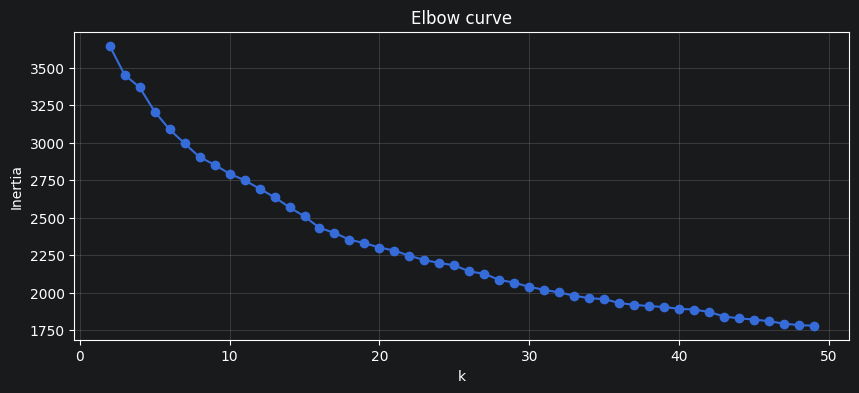

In [6]:
plt.figure(figsize=(10, 4))
plt.plot(k_values, inertias, marker="o", linewidth=1.5)
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow curve")
plt.grid(True, alpha=0.3)
plt.show()

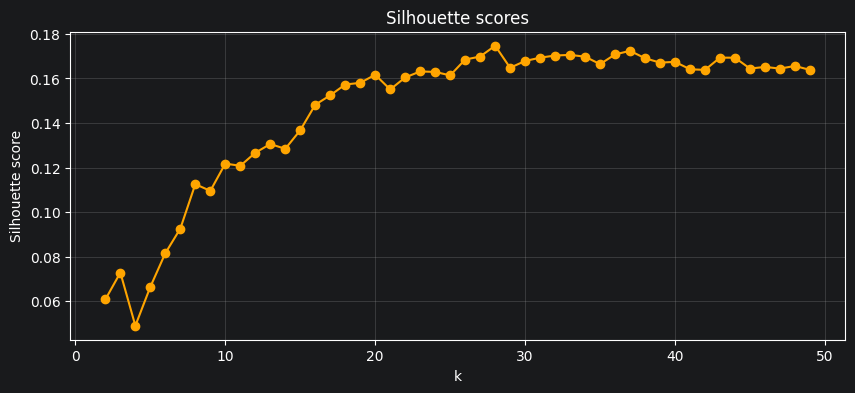

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(k_values, silhouette_scores, marker="o", linewidth=1.5, color="orange")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette scores")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
n_neighbors_options = [10, 15, 20, 30]
n_components_options = [30, 50, 75]
n_init_options = [10, 30]

results = []

print(f"{'n_neighbors':<13} {'n_components':<14} {'n_init':<8} {'best_k':<8} {'silhouette':<12} {'davies_bouldin':<16} {'confidence'}")
print("-" * 85)

for n_neighbors, n_components, n_init in itertools.product(
    n_neighbors_options, n_components_options, n_init_options
):
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=n_neighbors,
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )
    X_sweep = reducer.fit_transform(X)

    sil_scores = []
    db_scores = []
    inertias_sweep = []

    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=n_init)
        labels = km.fit_predict(X_sweep)
        inertias_sweep.append(km.inertia_)
        sil_scores.append(
            silhouette_score(X_sweep, labels, sample_size=3000, random_state=42)
        )
        db_scores.append(
            davies_bouldin_score(X_sweep, labels)
        )

    best_sil_k = k_values[sil_scores.index(max(sil_scores))]
    best_sil_score = max(sil_scores)
    best_db_score = db_scores[sil_scores.index(max(sil_scores))]

    kneedle_sweep = KneeLocator(
        k_values, inertias_sweep,
        curve="convex", direction="decreasing", S=0.5
    )
    elbow_k_sweep = kneedle_sweep.elbow
    diff = abs(elbow_k_sweep - best_sil_k)

    if diff <= 3:
        conf = "high"
    elif diff <= 10:
        conf = "medium"
    else:
        conf = "low"

    results.append({
        "n_neighbors": n_neighbors,
        "n_components": n_components,
        "n_init": n_init,
        "best_k": best_sil_k,
        "silhouette": round(best_sil_score, 4),
        "davies_bouldin": round(best_db_score, 4),
        "confidence": conf
    })

    print(f"{n_neighbors:<13} {n_components:<14} {n_init:<8} {best_sil_k:<8} {best_sil_score:<12.4f} {best_db_score:<16.4f} {conf}")

results_df = pd.DataFrame(results).sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True]
)
print(f"\n----- Top 5 combinations -----")
print(results_df.head())

n_neighbors   n_components   n_init   best_k   silhouette   davies_bouldin   confidence
-------------------------------------------------------------------------------------
10            30             10       31       0.8208       0.3363           low
10            30             30       31       0.8208       0.3363           low
10            50             10       42       0.8441       0.2929           low
10            50             30       40       0.8343       0.3166           low
10            75             10       46       0.8417       0.2752           low
10            75             30       44       0.8349       0.2737           low
15            30             10       26       0.8361       0.2337           medium
15            30             30       26       0.8361       0.2337           medium
15            50             10       27       0.8363       0.4256           medium
15            50             30       27       0.8363       0.4256           medium
15  

In [5]:
print("Fitting final model...")
print("UMAP : n_neighbors=30, n_components=30, min_dist=0.0, metric=cosine")
print("K-Means: k=22, n_init=10")

reducer_final = umap.UMAP(
    n_components=30,
    n_neighbors=30,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)
X_final = reducer_final.fit_transform(X)

km_final = KMeans(
    n_clusters=22,
    random_state=42,
    n_init=10
)
km_final.fit(X_final)

df["cluster_kmeans"] = km_final.labels_

final_sil = silhouette_score(X_final, km_final.labels_, sample_size=3000, random_state=42)
final_db = davies_bouldin_score(X_final, km_final.labels_)

print(f"\nDone.")
print(f"Silhouette     : {final_sil:.4f}")
print(f"Davies-Bouldin : {final_db:.4f}")
print(f"Inertia        : {km_final.inertia_:.1f}")
print(f"\nCluster size distribution:")
print(df["cluster_kmeans"].value_counts().sort_index())

Fitting final model...
UMAP : n_neighbors=30, n_components=30, min_dist=0.0, metric=cosine
K-Means: k=22, n_init=10


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.



Done.
Silhouette     : 0.8877
Davies-Bouldin : 0.1499
Inertia        : 6049.9

Cluster size distribution:
cluster_kmeans
0     554
1     403
2     160
3     198
4     204
5     514
6     323
7     686
8     213
9     216
10    205
11    194
12    160
13     85
14    142
15    185
16     45
17    113
18     62
19     42
20    178
21     53
Name: count, dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

def label_cluster(texts, top_n=4):
    if len(texts) < 2:
        return "too small"
    tfidf = TfidfVectorizer(stop_words="english", max_features=500)
    tfidf.fit_transform(texts)
    scores = zip(tfidf.get_feature_names_out(), tfidf.idf_)
    top = sorted(scores, key=lambda x: x[1])[:top_n]
    return ", ".join([w for w, _ in top])

print("Cluster labels via TF-IDF:")
print(f"{'Cluster':<10} {'Size':<8} {'Top keywords'}")
print("-" * 60)
for cluster_id in sorted(df["cluster_kmeans"].unique()):
    texts = df[df["cluster_kmeans"]==cluster_id]["text"].tolist()
    label = label_cluster(texts)
    size = len(texts)
    print(f"{cluster_id:<10} {size:<8} {label}")

Cluster labels via TF-IDF:
Cluster    Size     Top keywords
------------------------------------------------------------
0          554      order, purchase, help, need
1          403      address, delivery, shipping, help
2          160      termination, early, check, withdrawal
3          198      help, look, know, need
4          204      payment, methods, help, options
5          514      help, money, refund, need
6          323      customer, talk, assistance, help
7          686      account, need, help, standard
8          213      arrive, soon, expect, check
9          216      feedback, leave, help, product
10         205      claim, complaint, help, consumer
11         194      payment, online, payments, help
12         160      newsletter, help, corporate, unsubscribe
13         85       customer, hours, help, time
14         142      user, key, account, profile
15         185      sign, signup, inform, registration
16         45       newsletter, subscription, cancel, help


In [7]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(df["intent"], df["cluster_kmeans"])
nmi = normalized_mutual_info_score(df["intent"], df["cluster_kmeans"])

print(f"Adjusted Rand Index (ARI) : {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")

Adjusted Rand Index (ARI) : 0.5847
Normalized Mutual Info (NMI): 0.8640


In [8]:
print(f"df shape              : {df.shape}")
print(f"Columns               : {df.columns.tolist()}")
print(f"Intent nulls          : {df['intent'].isnull().sum()}")
print(f"Cluster nulls         : {df['cluster_kmeans'].isnull().sum()}")
print(f"Unique intents        : {df['intent'].nunique()}")
print(f"Unique clusters       : {df['cluster_kmeans'].nunique()}")

print(f"\nSample rows:")
print(df[["text", "intent", "cluster_kmeans"]].sample(8, random_state=42).to_string())

df shape              : (4935, 3)
Columns               : ['text', 'intent', 'cluster_kmeans']
Intent nulls          : 0
Cluster nulls         : 0
Unique intents        : 27
Unique clusters       : 22

Sample rows:
                                                    text                    intent  cluster_kmeans
1972             where to see when will my parcel arrive           delivery_period               8
4683                   where do i create a gold account?            create_account               7
151   what do i have to do to file a consumer complaint?                 complaint              10
2423                                  help creating user     registration_problems               7
1412                   i'm waiting for a restitution oof              track_refund               5
4209               i need to earn several items, help me               place_order               0
4169      assistance to talk with bloody customer supprt  contact_customer_service          

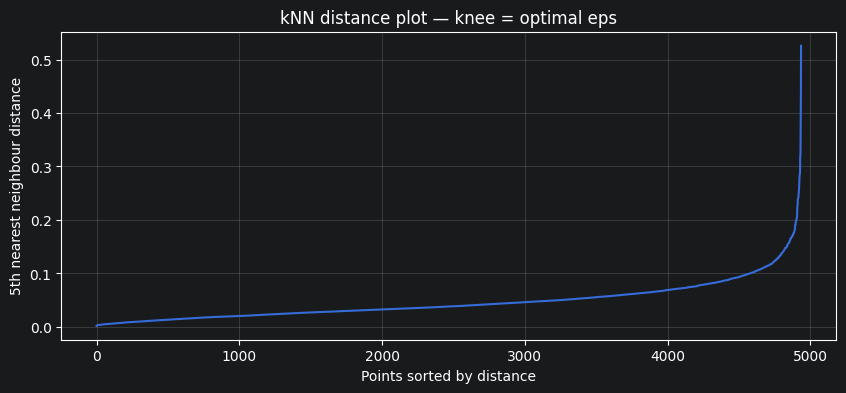

Distance range: 0.0021 — 0.5260
Median distance: 0.0381


In [9]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_final)
distances, _ = nn.kneighbors(X_final)

sorted_distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 4))
plt.plot(sorted_distances, linewidth=1.5)
plt.xlabel("Points sorted by distance")
plt.ylabel("5th nearest neighbour distance")
plt.title("kNN distance plot — knee = optimal eps")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Distance range: {sorted_distances.min():.4f} — {sorted_distances.max():.4f}")
print(f"Median distance: {np.median(sorted_distances):.4f}")

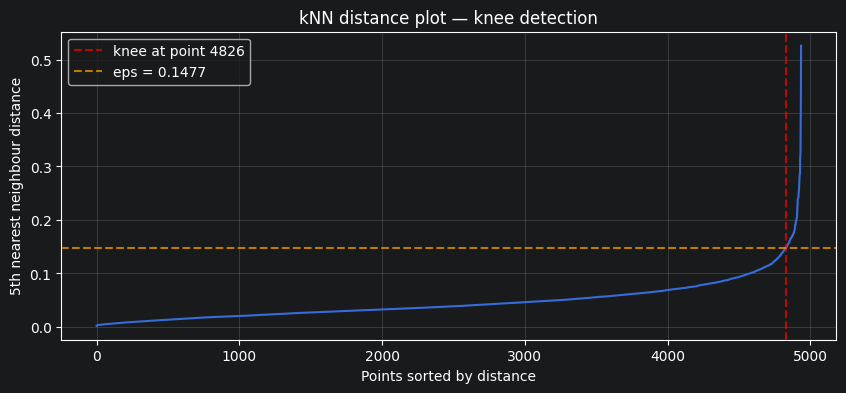

Knee at point : 4826
Suggested eps : 0.1477


In [10]:
from kneed import KneeLocator

knee = KneeLocator(
    range(len(sorted_distances)),
    sorted_distances,
    curve="convex",
    direction="increasing",
    S=1.0
)

eps = sorted_distances[knee.knee]

plt.figure(figsize=(10, 4))
plt.plot(sorted_distances, linewidth=1.5)
plt.axvline(x=knee.knee, color="red", linestyle="--",
            alpha=0.7, label=f"knee at point {knee.knee}")
plt.axhline(y=eps, color="orange", linestyle="--",
            alpha=0.7, label=f"eps = {eps:.4f}")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th nearest neighbour distance")
plt.title("kNN distance plot — knee detection")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Knee at point : {knee.knee}")
print(f"Suggested eps : {eps:.4f}")

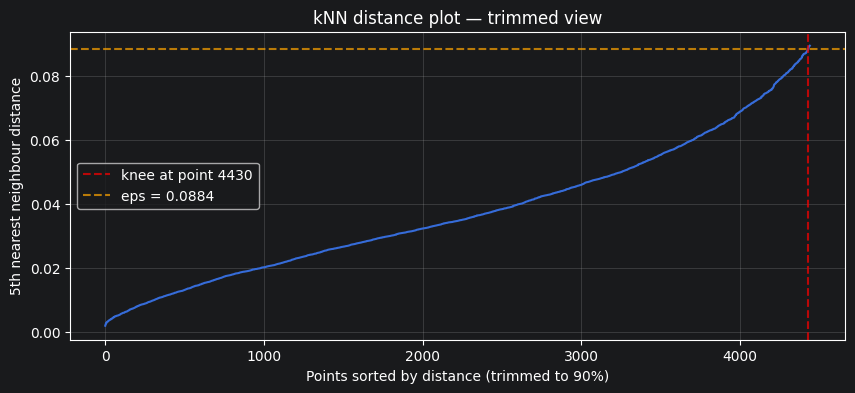

Knee at point : 4430
Suggested eps : 0.0884
Median dist   : 0.0381


In [11]:
cutoff = int(len(sorted_distances) * 0.90)
distances_trimmed = sorted_distances[:cutoff]

knee_trimmed = KneeLocator(
    range(len(distances_trimmed)),
    distances_trimmed,
    curve="convex",
    direction="increasing",
    S=1.0
)

eps_trimmed = sorted_distances[knee_trimmed.knee]

plt.figure(figsize=(10, 4))
plt.plot(distances_trimmed, linewidth=1.5)
plt.axvline(x=knee_trimmed.knee, color="red", linestyle="--",
            alpha=0.7, label=f"knee at point {knee_trimmed.knee}")
plt.axhline(y=eps_trimmed, color="orange", linestyle="--",
            alpha=0.7, label=f"eps = {eps_trimmed:.4f}")
plt.xlabel("Points sorted by distance (trimmed to 90%)")
plt.ylabel("5th nearest neighbour distance")
plt.title("kNN distance plot — trimmed view")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Knee at point : {knee_trimmed.knee}")
print(f"Suggested eps : {eps_trimmed:.4f}")
print(f"Median dist   : {np.median(sorted_distances):.4f}")

In [12]:
from sklearn.cluster import DBSCAN

eps_values = [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.20]
min_samples_values = [5, 10, 30, 60]  # 60 = 2 × n_components (rule of thumb)

print(f"{'eps':<8} {'min_samples':<13} {'n_clusters':<12} {'noise_pts':<12} {'noise_%'}")
print("-" * 58)

for min_samples in min_samples_values:
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_final)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100

        print(f"{eps:<8} {min_samples:<13} {n_clusters:<12} {n_noise:<12} {noise_pct:.1f}%")
    print()

eps      min_samples   n_clusters   noise_pts    noise_%
----------------------------------------------------------
0.01     5             55           4494         91.1%
0.02     5             145          3579         72.5%
0.03     5             211          2611         52.9%
0.05     5             221          1150         23.3%
0.08     5             168          345          7.0%
0.1      5             140          172          3.5%
0.15     5             98           41           0.8%
0.2      5             83           16           0.3%

0.01     10            10           4811         97.5%
0.02     10            38           4428         89.7%
0.03     10            72           3877         78.6%
0.05     10            154          2140         43.4%
0.08     10            153          660          13.4%
0.1      10            144          329          6.7%
0.15     10            97           116          2.4%
0.2      10            83           41           0.8%

0.01     

In [13]:
eps_values_extended = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
min_samples_values = [5, 10]

print(f"{'eps':<8} {'min_samples':<13} {'n_clusters':<12} {'noise_pts':<12} {'noise_%'}")
print("-" * 58)

for min_samples in min_samples_values:
    for eps in eps_values_extended:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_final)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100
        print(f"{eps:<8} {min_samples:<13} {n_clusters:<12} {n_noise:<12} {noise_pct:.1f}%")
    print()

eps      min_samples   n_clusters   noise_pts    noise_%
----------------------------------------------------------
0.2      5             83           16           0.3%
0.25     5             67           11           0.2%
0.3      5             58           2            0.0%
0.35     5             53           2            0.0%
0.4      5             49           1            0.0%
0.5      5             44           0            0.0%

0.2      10            83           41           0.8%
0.25     10            68           20           0.4%
0.3      10            59           4            0.1%
0.35     10            55           2            0.0%
0.4      10            49           1            0.0%
0.5      10            44           0            0.0%



In [14]:
from sklearn.cluster import DBSCAN

umap_configs = [
    {"n_neighbors": 15, "n_components": 50},
    {"n_neighbors": 15, "n_components": 30},
    {"n_neighbors": 10, "n_components": 30},
]

eps_values = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
min_samples_values = [5, 10]

for config in umap_configs:
    print(f"\n{'='*65}")
    print(f"UMAP: n_neighbors={config['n_neighbors']}, n_components={config['n_components']}")
    print(f"{'='*65}")

    reducer_db = umap.UMAP(
        n_components=config["n_components"],
        n_neighbors=config["n_neighbors"],
        min_dist=0.0,
        metric="cosine",
        random_state=42
    )
    X_db = reducer_db.fit_transform(X)

    print(f"{'eps':<8} {'min_samples':<13} {'n_clusters':<12} {'noise_pts':<12} {'noise_%'}")
    print("-" * 58)

    for min_samples in min_samples_values:
        for eps in eps_values:
            db = DBSCAN(eps=eps, min_samples=min_samples)
            labels = db.fit_predict(X_db)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            n_noise = (labels == -1).sum()
            noise_pct = n_noise / len(labels) * 100
            print(f"{eps:<8} {min_samples:<13} {n_clusters:<12} {n_noise:<12} {noise_pct:.1f}%")
        print()


UMAP: n_neighbors=15, n_components=50
eps      min_samples   n_clusters   noise_pts    noise_%
----------------------------------------------------------
0.1      5             173          198          4.0%
0.15     5             131          73           1.5%
0.2      5             117          37           0.7%
0.25     5             98           18           0.4%
0.3      5             84           3            0.1%
0.35     5             75           1            0.0%
0.4      5             68           0            0.0%
0.5      5             62           0            0.0%

0.1      10            167          469          9.5%
0.15     10            129          149          3.0%
0.2      10            115          70           1.4%
0.25     10            100          45           0.9%
0.3      10            85           13           0.3%
0.35     10            76           5            0.1%
0.4      10            69           0            0.0%
0.5      10            62         

In [15]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import silhouette_score, davies_bouldin_score

# fit final UMAP for DBSCAN
reducer_dbscan_final = umap.UMAP(
    n_components=50,
    n_neighbors=15,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)
X_dbscan_final = reducer_dbscan_final.fit_transform(X)

# fit DBSCAN
db_final = DBSCAN(eps=0.5, min_samples=5)
db_labels = db_final.fit_predict(X_dbscan_final)

df["cluster_dbscan"] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = (db_labels == -1).sum()

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise}")

mask = db_labels != -1
labels_clean = db_labels[mask]
X_clean = X_dbscan_final[mask]
df_clean = df[mask]

sil = silhouette_score(X_clean, labels_clean, sample_size=3000, random_state=42)
db_score = davies_bouldin_score(X_clean, labels_clean)
ari = adjusted_rand_score(df_clean["intent"], labels_clean)
nmi = normalized_mutual_info_score(df_clean["intent"], labels_clean)

print(f"\n----- DBSCAN Evaluation -----")
print(f"Silhouette     : {sil:.4f}")
print(f"Davies-Bouldin : {db_score:.4f}")
print(f"ARI            : {ari:.4f}")
print(f"NMI            : {nmi:.4f}")

print(f"\n----- K-Means vs DBSCAN -----")
print(f"{'Metric':<20} {'K-Means':<12} {'DBSCAN'}")
print("-" * 45)
print(f"{'Silhouette':<20} {0.8877:<12} {sil:.4f}")
print(f"{'Davies-Bouldin':<20} {0.1499:<12} {db_score:.4f}")
print(f"{'ARI':<20} {0.5847:<12} {ari:.4f}")
print(f"{'NMI':<20} {0.8640:<12} {nmi:.4f}")
print(f"{'N clusters':<20} {22:<12} {n_clusters}")
print(f"{'Noise points':<20} {0:<12} {n_noise}")

Clusters found : 62
Noise points   : 0

----- DBSCAN Evaluation -----
Silhouette     : 0.7577
Davies-Bouldin : 0.2913
ARI            : 0.5703
NMI            : 0.8188

----- K-Means vs DBSCAN -----
Metric               K-Means      DBSCAN
---------------------------------------------
Silhouette           0.8877       0.7577
Davies-Bouldin       0.1499       0.2913
ARI                  0.5847       0.5703
NMI                  0.864        0.8188
N clusters           22           62
Noise points         0            0


In [16]:
eps_values = [0.20, 0.25, 0.30, 0.35, 0.40, 0.50]
min_samples_values = [5, 10]

print("DBSCAN on K-Means UMAP space (n_neighbors=30, n_components=30)")
print(f"\n{'eps':<8} {'min_samples':<13} {'n_clusters':<12} {'noise_pts':<12} {'noise_%'}")
print("-" * 58)

for min_samples in min_samples_values:
    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_final)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100
        print(f"{eps:<8} {min_samples:<13} {n_clusters:<12} {n_noise:<12} {noise_pct:.1f}%")
    print()

DBSCAN on K-Means UMAP space (n_neighbors=30, n_components=30)

eps      min_samples   n_clusters   noise_pts    noise_%
----------------------------------------------------------
0.2      5             83           16           0.3%
0.25     5             67           11           0.2%
0.3      5             58           2            0.0%
0.35     5             53           2            0.0%
0.4      5             49           1            0.0%
0.5      5             44           0            0.0%

0.2      10            83           41           0.8%
0.25     10            68           20           0.4%
0.3      10            59           4            0.1%
0.35     10            55           2            0.0%
0.4      10            49           1            0.0%
0.5      10            44           0            0.0%



In [17]:
db_fair = DBSCAN(eps=0.5, min_samples=5)
db_labels_fair = db_fair.fit_predict(X_final)

df["cluster_dbscan"] = db_labels_fair

n_clusters = len(set(db_labels_fair)) - (1 if -1 in db_labels_fair else 0)
n_noise = (db_labels_fair == -1).sum()

mask = db_labels_fair != -1
labels_clean = db_labels_fair[mask]
X_clean = X_final[mask]
df_clean = df[mask]

sil = silhouette_score(X_clean, labels_clean, sample_size=3000, random_state=42)
db_score = davies_bouldin_score(X_clean, labels_clean)
ari = adjusted_rand_score(df_clean["intent"], labels_clean)
nmi = normalized_mutual_info_score(df_clean["intent"], labels_clean)

print(f"----- Fair Comparison (same UMAP space) -----")
print(f"{'Metric':<20} {'K-Means':<12} {'DBSCAN'}")
print("-" * 45)
print(f"{'Silhouette':<20} {0.8877:<12} {sil:.4f}")
print(f"{'Davies-Bouldin':<20} {0.1499:<12} {db_score:.4f}")
print(f"{'ARI':<20} {0.5847:<12} {ari:.4f}")
print(f"{'NMI':<20} {0.8640:<12} {nmi:.4f}")
print(f"{'N clusters':<20} {22:<12} {n_clusters}")
print(f"{'Noise points':<20} {0:<12} {n_noise}")
print(f"\nNote: both evaluated on identical UMAP space")
print(f"UMAP: n_neighbors=30, n_components=30, min_dist=0.0, metric=cosine")

----- Fair Comparison (same UMAP space) -----
Metric               K-Means      DBSCAN
---------------------------------------------
Silhouette           0.8877       0.7243
Davies-Bouldin       0.1499       0.3257
ARI                  0.5847       0.6008
NMI                  0.864        0.8315
N clusters           22           44
Noise points         0            0

Note: both evaluated on identical UMAP space
UMAP: n_neighbors=30, n_components=30, min_dist=0.0, metric=cosine


In [18]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

umap_configs = [
    {"n_neighbors": 10, "n_components": 30},
    {"n_neighbors": 10, "n_components": 50},
    {"n_neighbors": 15, "n_components": 30},
    {"n_neighbors": 15, "n_components": 50},
    {"n_neighbors": 20, "n_components": 30},
    {"n_neighbors": 20, "n_components": 50},
    {"n_neighbors": 30, "n_components": 30},
    {"n_neighbors": 30, "n_components": 50},
]

eps_values = [0.3, 0.4, 0.5, 0.6, 0.7]
min_samples = 5

results_dbscan = []
umap_cache_db = {}

print(f"{'n_neighbors':<13} {'n_components':<14} {'eps':<7} {'n_clusters':<12} {'noise_%':<10} {'silhouette':<12} {'db_score':<10} {'ari':<8} {'nmi'}")
print("-" * 100)

for config in umap_configs:
    cache_key = (config["n_neighbors"], config["n_components"])
    if cache_key not in umap_cache_db:
        reducer = umap.UMAP(
            n_components=config["n_components"],
            n_neighbors=config["n_neighbors"],
            min_dist=0.0,
            metric="cosine",
            random_state=42
        )
        umap_cache_db[cache_key] = reducer.fit_transform(X)

    X_db = umap_cache_db[cache_key]

    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_db)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = (labels == -1).sum()
        noise_pct = n_noise / len(labels) * 100

        if n_clusters < 2:
            continue

        mask = labels != -1
        if mask.sum() < 100:
            continue

        labels_clean = labels[mask]
        X_clean = X_db[mask]
        df_clean = df[mask]

        sil = silhouette_score(X_clean, labels_clean, sample_size=3000, random_state=42)
        db_score = davies_bouldin_score(X_clean, labels_clean)
        ari = adjusted_rand_score(df_clean["intent"], labels_clean)
        nmi = normalized_mutual_info_score(df_clean["intent"], labels_clean)

        results_dbscan.append({
            "n_neighbors": config["n_neighbors"],
            "n_components": config["n_components"],
            "eps": eps,
            "n_clusters": n_clusters,
            "noise_pct": round(noise_pct, 1),
            "silhouette": round(sil, 4),
            "davies_bouldin": round(db_score, 4),
            "ari": round(ari, 4),
            "nmi": round(nmi, 4)
        })

        print(f"{config['n_neighbors']:<13} {config['n_components']:<14} {eps:<7} {n_clusters:<12} {noise_pct:<10.1f} {sil:<12.4f} {db_score:<10.4f} {ari:<8.4f} {nmi:.4f}")

results_dbscan_df = pd.DataFrame(results_dbscan).sort_values(
    ["silhouette", "davies_bouldin"],
    ascending=[False, True]
)

print(f"\n----- Top 5 DBSCAN combinations -----")
print(results_dbscan_df.head())

n_neighbors   n_components   eps     n_clusters   noise_%    silhouette   db_score   ari      nmi
----------------------------------------------------------------------------------------------------
10            30             0.3     114          0.1        0.7523       0.2662     0.4424   0.7974
10            30             0.4     100          0.0        0.6837       0.3155     0.4708   0.7941
10            30             0.5     85           0.0        0.7299       0.2980     0.5247   0.8074
10            30             0.6     75           0.0        0.7449       0.2922     0.5502   0.8148
10            30             0.7     67           0.0        0.7384       0.2891     0.5696   0.8181
10            50             0.3     114          0.2        0.7359       0.2899     0.4522   0.7990
10            50             0.4     96           0.1        0.7124       0.3000     0.5112   0.8102
10            50             0.5     80           0.0        0.7409       0.2765     0.5422   